In [ ]:

import torch
import torch.nn as nn
import numpy as np
import warnings
from torch.utils.data import Dataset, DataLoader

import os
from transformers import AutoModel
from utils.tokenizersM import get_ntv3_tokenizer
import math
import torch.nn.functional as F
import random
warnings.filterwarnings('ignore')

# Ensure reproducibility: make results consistent across runs
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(42)

def _read_signal_file(file, m=False):
    signals = [] 
    with open(file) as f:

        for line in f:
            parts = line.strip().split()
            if m:
                signal_values = [x * 0.01 for x in map(float, parts[4:])]
            else:
                signal_values = list(map(float, parts[4:]))  # 从第5列开始读取200个值

            signals.append(signal_values)

    signals = torch.tensor(signals, dtype=torch.float32)
    # pad = torch.zeros(signals.size(0), 1)  # [N, 1]

    # signals = torch.cat([pad, signals, pad], dim=-1)
    return  signals  

        
class GenomicDataset(Dataset):
    def __init__(self, fasta_pos_fu, methylation_pos_fusame,  fasta_pos_z, methylation_pos_zsame, 
    fasta_neg_fu, methylation_neg_fusame, fasta_neg_z, methylation_neg_zsame, 
    Dnase_Z_F, Dnase_Z_Z, Dnase_F_F, Dnase_F_Z, myname
   
    ):
        self.fasta_pos = self.read_fasta(fasta_pos_fu) + self.read_fasta(fasta_pos_z) 
        self.fasta_neg = self.read_fasta(fasta_neg_fu) + self.read_fasta(fasta_neg_z) 
        sequences = self.fasta_pos + self.fasta_neg
 
        # 初始化 tokenizer
        tokenizer = get_ntv3_tokenizer()

        # tokenizer 输出 numpy array
        tokens_np = tokenizer.batch_np_tokenize(sequences)  # shape: [batch, seq_len]
        self.input_ids = torch.tensor(tokens_np, dtype=torch.long)

        # Dnase_Z_F = _read_signal_file(Dnase_Z_F)
        # Dnase_Z_Z = _read_signal_file(Dnase_Z_Z)
        # Dnase_F_F = _read_signal_file(Dnase_F_F)
        # Dnase_F_Z = _read_signal_file(Dnase_F_Z)
        # self.Dnase = np.concatenate([
        #                     torch.flip(Dnase_Z_F, dims=[1])  , 
        #                     Dnase_Z_Z , 
        #                     torch.flip(Dnase_F_F, dims=[1]) , 
        #                     Dnase_F_Z, 
        #                     ], axis=0)

        # self.labels = np.array([1] * len(self.fasta_pos) + [0] * len(self.fasta_neg))

        # # Save preprocessed features if not exist
        labels_path = f'L1k_1_k_{myname}_labels_S.pt'
        if os.path.exists(labels_path):
            print(f"{labels_path} already exists. Loading labels...")
            self.labels = torch.load(labels_path)#.numpy()
            # self.labels2 = torch.load(f'/home/hjzhang/dataset/home-1/ylxiong/Center/Hela_input/processed/Hela_labels.pt')#.numpy()
            # self.labels = torch.cat([ self.labels , self.labels2],0) # 添加首尾

        else:
            torch.save(torch.tensor(self.labels, dtype=torch.int32), labels_path)
            print(f"Saved labels to {labels_path}")

        # methylation_pos_fudif = _read_signal_file(methylation_pos_fusame  ,m=True)
        # methylation_pos_zdif = _read_signal_file(methylation_pos_zsame ,m=True)
        # methylation_neg_fudif = _read_signal_file(methylation_neg_fusame ,m=True)
        # methylation_neg_zdif = _read_signal_file(methylation_neg_zsame ,m=True)

        # self.methylation = np.concatenate([
        #                     torch.flip(methylation_pos_fudif, dims=[1])  , 
        #                     methylation_pos_zdif , 
        #                     torch.flip(methylation_neg_fudif, dims=[1]) , 
        #                     methylation_neg_zdif , 
        #                     ], axis=0)
             

        epi_path = f'L1k_1_k_{myname}_epis_WGBS_3_S.pt'
        if os.path.exists(epi_path):
            print(f"{epi_path} already exists. Loading compressed features...")
            self.epi = torch.load(epi_path).float() 
            # self.epi2 = torch.load(f'/home/hjzhang/dataset/home-1/ylxiong/Center/Hela_input/processed/Hela_epis_WGBS.pt').float()
            # self.epi = torch.cat([ self.epi , self.epi2],0) # 添加首尾
            print(self.epi.max())

        else:
            print("Computing and saving compressed epi features...")
            epi_tensor = torch.tensor( self.methylation[:, :, np.newaxis]  , dtype=torch.float32)
            self.epi = epi_tensor.float()
            print(f"Saved compressed epi features to {epi_path}")
            torch.save(self.epi, epi_path)


        Dnase_path = f'L1k_1_k_{myname}_epis_dnase_S.pt'
        if os.path.exists(Dnase_path):
            print(f"{Dnase_path} already exists. Loading compressed features...")
            self.Dnase = torch.log1p(torch.load(Dnase_path).float())
            print(self.Dnase.max())

        else:
            print("Computing and saving compressed epi features...")
            epi_tensor = torch.tensor( self.Dnase[:, :, np.newaxis]  , dtype=torch.float32)
            torch.save(epi_tensor, Dnase_path)
            self.Dnase = torch.log1p( epi_tensor.float())
            print(f"Saved compressed epi features to {Dnase_path}")

    def read_fasta(self, file):
        seqs = []
        with open(file) as f:
            seq = ''
            for line in f:
                if line.startswith('>'):
                    if seq:
                        seqs.append(seq.upper())
                        seq = ''
                else:
                    seq += line.strip()
            if seq:
                seqs.append(seq.upper())
        return seqs

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        train_seq = torch.cat([ self.Dnase[idx],  self.epi[idx]],-1) # 添加首尾

        return (
            self.input_ids[idx] ,  train_seq ,
            torch.tensor(self.labels[idx], dtype=torch.long),  idx  # 新增

        )


class AdaptiveLayerNorm(nn.LayerNorm):
    """LayerNorm that applies per-condition affine modulation."""

    def __init__(
        self, num_features: int, conditions_dims: list[int], epsilon: float = 1e-5
    ):
        super().__init__(
            normalized_shape=num_features, eps=epsilon, elementwise_affine=True
        )
        self.modulation_layers = nn.ModuleList(
            [nn.Linear(cd, 2 * num_features) for cd in conditions_dims]
        )
        self._num_conditions = len(conditions_dims)
        self._dim = num_features

    def forward(  # type: ignore[override]
        self,
        x: torch.Tensor,
        conditions: list[torch.Tensor],
        conditions_masks: list[torch.Tensor] | None = None,
    ) -> torch.Tensor:
        x = self._base_ln_fp32(x)

        if len(conditions) != self._num_conditions:
            raise ValueError("Number of conditions mismatch")

        if conditions_masks is None:
            conditions_masks = [
                torch.ones(x.shape[0], dtype=x.dtype, device=x.device)
                for _ in conditions
            ]

        scale = torch.ones_like(x[:, :1, :])
        shift = torch.zeros_like(x[:, :1, :])

        for i, cond in enumerate(conditions):
            cond_cast = cond.to(self.modulation_layers[i].weight.dtype)
            tmp = self.modulation_layers[i](cond_cast).unsqueeze(1)
            tmp = tmp.to(x.dtype)
            shift_i, scale_i = torch.chunk(tmp, 2, dim=-1)
            mask = conditions_masks[i].unsqueeze(-1).unsqueeze(-1)
            shift_i = torch.where(mask.bool(), shift_i, 0.0)
            scale_i = torch.where(mask.bool(), scale_i, 0.0)
            scale = scale * (1.0 + scale_i)
            shift = shift + shift_i

        return x * scale + shift

    def _base_ln_fp32(self, x: torch.Tensor) -> torch.Tensor:
        """Run base LayerNorm in fp32 (compiler-friendly, like Mistral/Gemma)."""
        # Compute in fp32
        x_fp32 = x.to(torch.float32)
        mean = x_fp32.mean(dim=-1, keepdim=True)
        var = ((x_fp32 - mean) ** 2).mean(dim=-1, keepdim=True)
        x_normed = (x_fp32 - mean) * torch.rsqrt(var + self.eps)
        
        # Apply inherited weight/bias in fp32, then cast back
        if self.weight is not None:
            x_normed = x_normed * self.weight.to(torch.float32)
        if self.bias is not None:
            x_normed = x_normed + self.bias.to(torch.float32)
        
        return x_normed.type_as(x)

class MultiHeadAttention(nn.Module):
    """
    A vanilla multi-head masked self-attention layer with a projection at the end.
    It is possible to use torch.nn.MultiheadAttention here but I am including an
    explicit implementation here to show that there is nothing too scary here.
    """

    def __init__(self, n_embd):
        super().__init__()
        n_head = 12
        block_size = 1024
        # key, query, value projections for all heads
        self.key = nn.Linear(n_embd, n_embd)
        self.query = nn.Linear(n_embd, n_embd)
        self.value = nn.Linear(n_embd, n_embd)
        # regularization
        self.attn_drop = nn.Dropout(0.1)
        self.resid_drop = nn.Dropout(0.1)
        # output projection
        self.proj = nn.Linear(n_embd, n_embd)
        # causal mask to ensure that attention is only applied to the left in the input sequence
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size))
                             .view(1, 1, block_size, block_size))

        self.n_head = n_head        

    def forward(self, q, k, v, layer_past=None, condition=None, mask=True):
        B, T, C = q.size()

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        k = self.key(k).view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = self.query(q).view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = self.value(v).view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

        # causal self-attention; Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))

        if mask:
            att = att.masked_fill(self.mask[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        attn_save = att
        att = self.attn_drop(att)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side

        # output projection
        y = self.resid_drop(self.proj(y))
        return y, attn_save

class Block(nn.Module):
    """ an unassuming Transformer block """

    def __init__(self, n_embd):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
        self.attn = MultiHeadAttention(n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(0.1),
        )

    def forward(self, condition=None, mask=True):
        x = self.ln1(x)
        y, attn = self.attn(condition=condition, mask=mask)
        x = x + y
        x = x + self.mlp(self.ln2(x))
        return attn


all_attn = {}
lr = 3e-5
batch_size = 1


name_list = ["A549", # 1
            "K562",   # 2
            "HepG2", # 3
            "293T", # 4
            ]
name = name_list[0]
name2 = name_list[1]
name3 = name_list[2]
name4 = name_list[3]

if True:
    if True:
        dataset = GenomicDataset(   
                f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/G4_1k.suF.fa",
                f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/G4_1k.suF_F.tsv",
                f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/G4_1k.suF_Z.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/G4_1k.suZ.fa",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/G4_1k.suZ_Z.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/G4_1k.suZ_F.tsv",

                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/noG4_1k.suF.fa",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/noG4_1k.suF_F.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/noG4_1k.suF_Z.tsv",

                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/noG4_1k.suZ.fa",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/noG4_1k.suZ_Z.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/noG4_1k.suZ_F.tsv",

                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/G4_1k.suF_D.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/G4_1k.suZ_D.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/noG4_1k.suF_D.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name}_1k/noG4_1k.suZ_D.tsv", name
                )
        dataset2 = GenomicDataset(   
                f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/G4_1k.suF.fa",
                f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/G4_1k.suF_F.tsv",
                f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/G4_1k.suF_Z.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/G4_1k.suZ.fa",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/G4_1k.suZ_Z.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/G4_1k.suZ_F.tsv",

                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/noG4_1k.suF.fa",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/noG4_1k.suF_F.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/noG4_1k.suF_Z.tsv",

                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/noG4_1k.suZ.fa",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/noG4_1k.suZ_Z.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/noG4_1k.suZ_F.tsv",

                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/G4_1k.suF_D.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/G4_1k.suZ_D.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/noG4_1k.suF_D.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name2}_1k/noG4_1k.suZ_D.tsv", name2
                )
        dataset3 = GenomicDataset(   
                f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/G4_1k.suF.fa",
                f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/G4_1k.suF_F.tsv",
                f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/G4_1k.suF_Z.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/G4_1k.suZ.fa",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/G4_1k.suZ_Z.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/G4_1k.suZ_F.tsv",

                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/noG4_1k.suF.fa",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/noG4_1k.suF_F.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/noG4_1k.suF_Z.tsv",

                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/noG4_1k.suZ.fa",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/noG4_1k.suZ_Z.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/noG4_1k.suZ_F.tsv",

                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/G4_1k.suF_D.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/G4_1k.suZ_D.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/noG4_1k.suF_D.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name3}_1k/noG4_1k.suZ_D.tsv", name3
                )
        dataset4 = GenomicDataset(   
                f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/G4_1k.suF.fa",
                f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/G4_1k.suF_F.tsv",
                f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/G4_1k.suF_Z.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/G4_1k.suZ.fa",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/G4_1k.suZ_Z.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/G4_1k.suZ_F.tsv",

                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/noG4_1k.suF.fa",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/noG4_1k.suF_F.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/noG4_1k.suF_Z.tsv",

                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/noG4_1k.suZ.fa",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/noG4_1k.suZ_Z.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/noG4_1k.suZ_F.tsv",

                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/G4_1k.suF_D.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/G4_1k.suZ_D.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/noG4_1k.suF_D.tsv",
                                        f"home/hjzhang/dataset/home-1/ylxiong/_update/Intervene_results/{name4}_1k/noG4_1k.suZ_D.tsv", name4
                )


/home/hjzhang/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


L1k_1_k_A549_labels_S.pt already exists. Loading labels...
L1k_1_k_A549_epis_WGBS_3_S.pt already exists. Loading compressed features...
tensor(1.)
L1k_1_k_A549_epis_dnase_S.pt already exists. Loading compressed features...
tensor(8.9041)
L1k_1_k_K562_labels_S.pt already exists. Loading labels...
L1k_1_k_K562_epis_WGBS_3_S.pt already exists. Loading compressed features...
tensor(1.)
L1k_1_k_K562_epis_dnase_S.pt already exists. Loading compressed features...
tensor(4.7628)
L1k_1_k_HepG2_labels_S.pt already exists. Loading labels...
L1k_1_k_HepG2_epis_WGBS_3_S.pt already exists. Loading compressed features...
tensor(1.)
L1k_1_k_HepG2_epis_dnase_S.pt already exists. Loading compressed features...
tensor(4.0464)
L1k_1_k_293T_labels_S.pt already exists. Loading labels...
L1k_1_k_293T_epis_WGBS_3_S.pt already exists. Loading compressed features...
tensor(1.)
L1k_1_k_293T_epis_dnase_S.pt already exists. Loading compressed features...
tensor(4.9936)


Loading existing split indices from L1k_1_k_A549_test_idx_label_diff.pt
Loading existing split indices from L1k_1_k_K562_test_idx_label_diff.pt
Loading existing split indices from L1k_1_k_HepG2_test_idx_label_diff.pt
Loading existing split indices from L1k_1_k_293T_test_idx_label_diff.pt
1008


Some weights of the model checkpoint at /home/hjzhang/ntv3G4/nucleotide_transformer_v3/NTv3_100m_post were not used when initializing NTv3PostTrained: ['core.bed_head.head.bias', 'core.bed_head.head.weight', 'core.bed_head.layer_norm.bias', 'core.bed_head.layer_norm.weight', 'core.bigwig_head.species_heads.13.head.bias', 'core.bigwig_head.species_heads.13.head.weight', 'core.bigwig_head.species_heads.13.layer_norm.bias', 'core.bigwig_head.species_heads.13.layer_norm.weight', 'core.bigwig_head.species_heads.16.head.bias', 'core.bigwig_head.species_heads.16.head.weight', 'core.bigwig_head.species_heads.16.layer_norm.bias', 'core.bigwig_head.species_heads.16.layer_norm.weight', 'core.bigwig_head.species_heads.18.head.bias', 'core.bigwig_head.species_heads.18.head.weight', 'core.bigwig_head.species_heads.18.layer_norm.bias', 'core.bigwig_head.species_heads.18.layer_norm.weight', 'core.bigwig_head.species_heads.21.head.bias', 'core.bigwig_head.species_heads.21.head.weight', 'core.bigwig_hea

18818
tensor([[ 1.6802, -0.5231]], device='cuda:2')
tensor([[ 1.6363, -0.4915]], device='cuda:2')


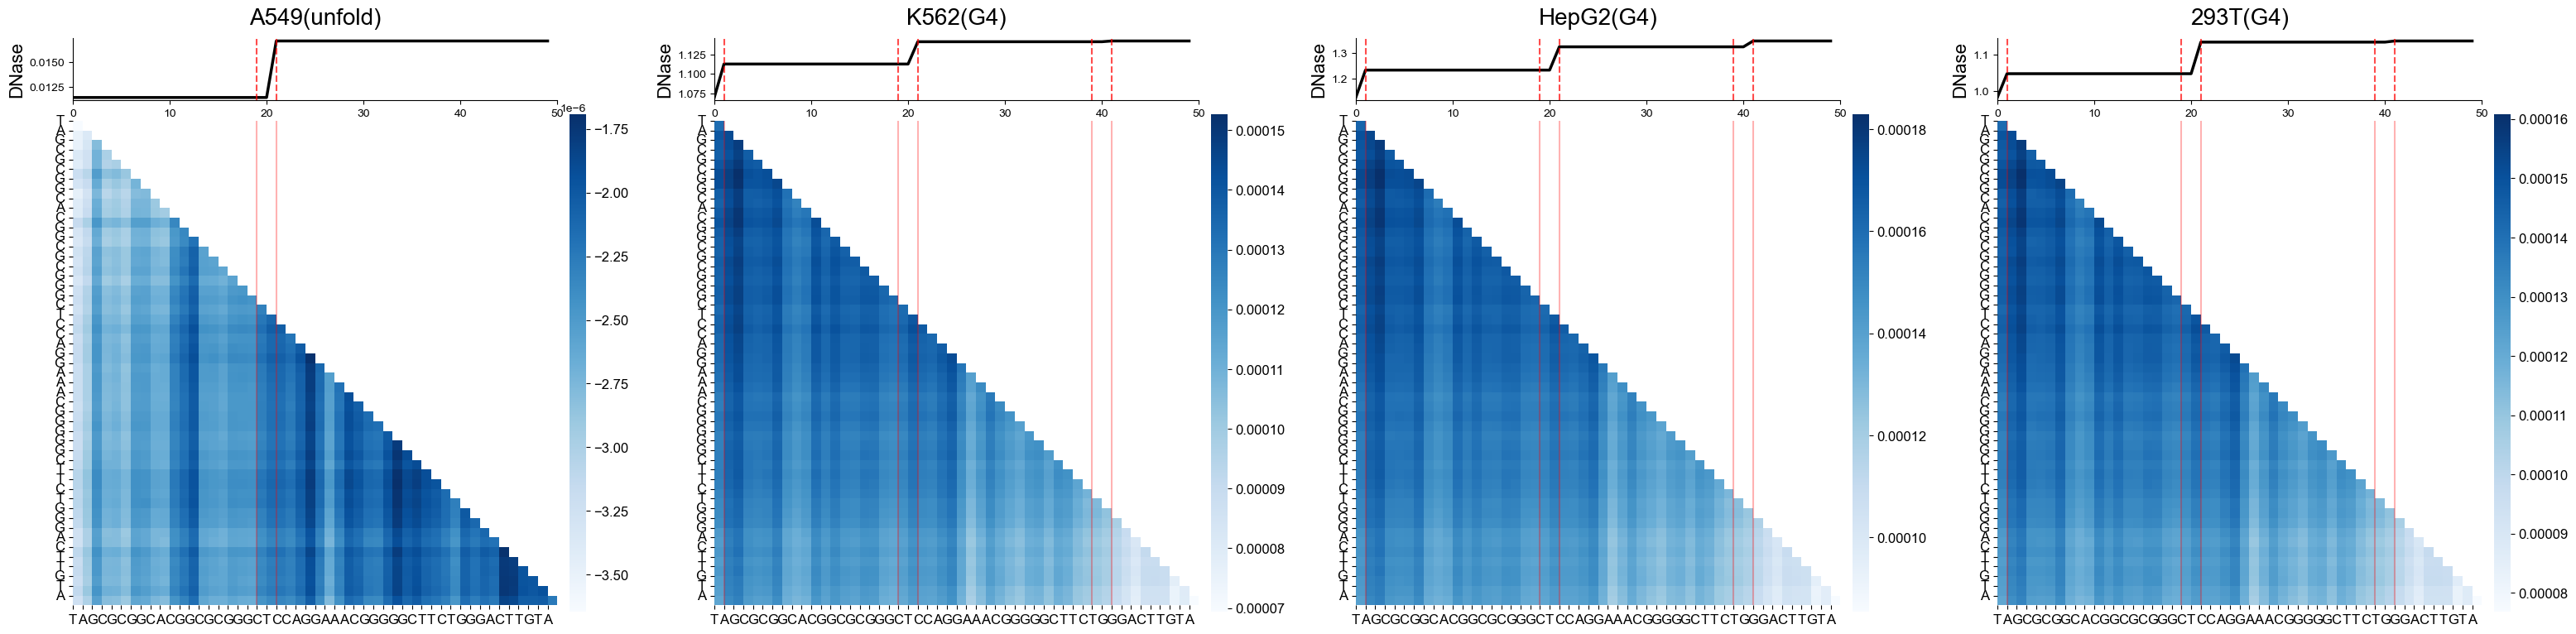

13
tensor([[ 1.1309, -0.3346]], device='cuda:2')
tensor([[-3.6835,  3.4432]], device='cuda:2')


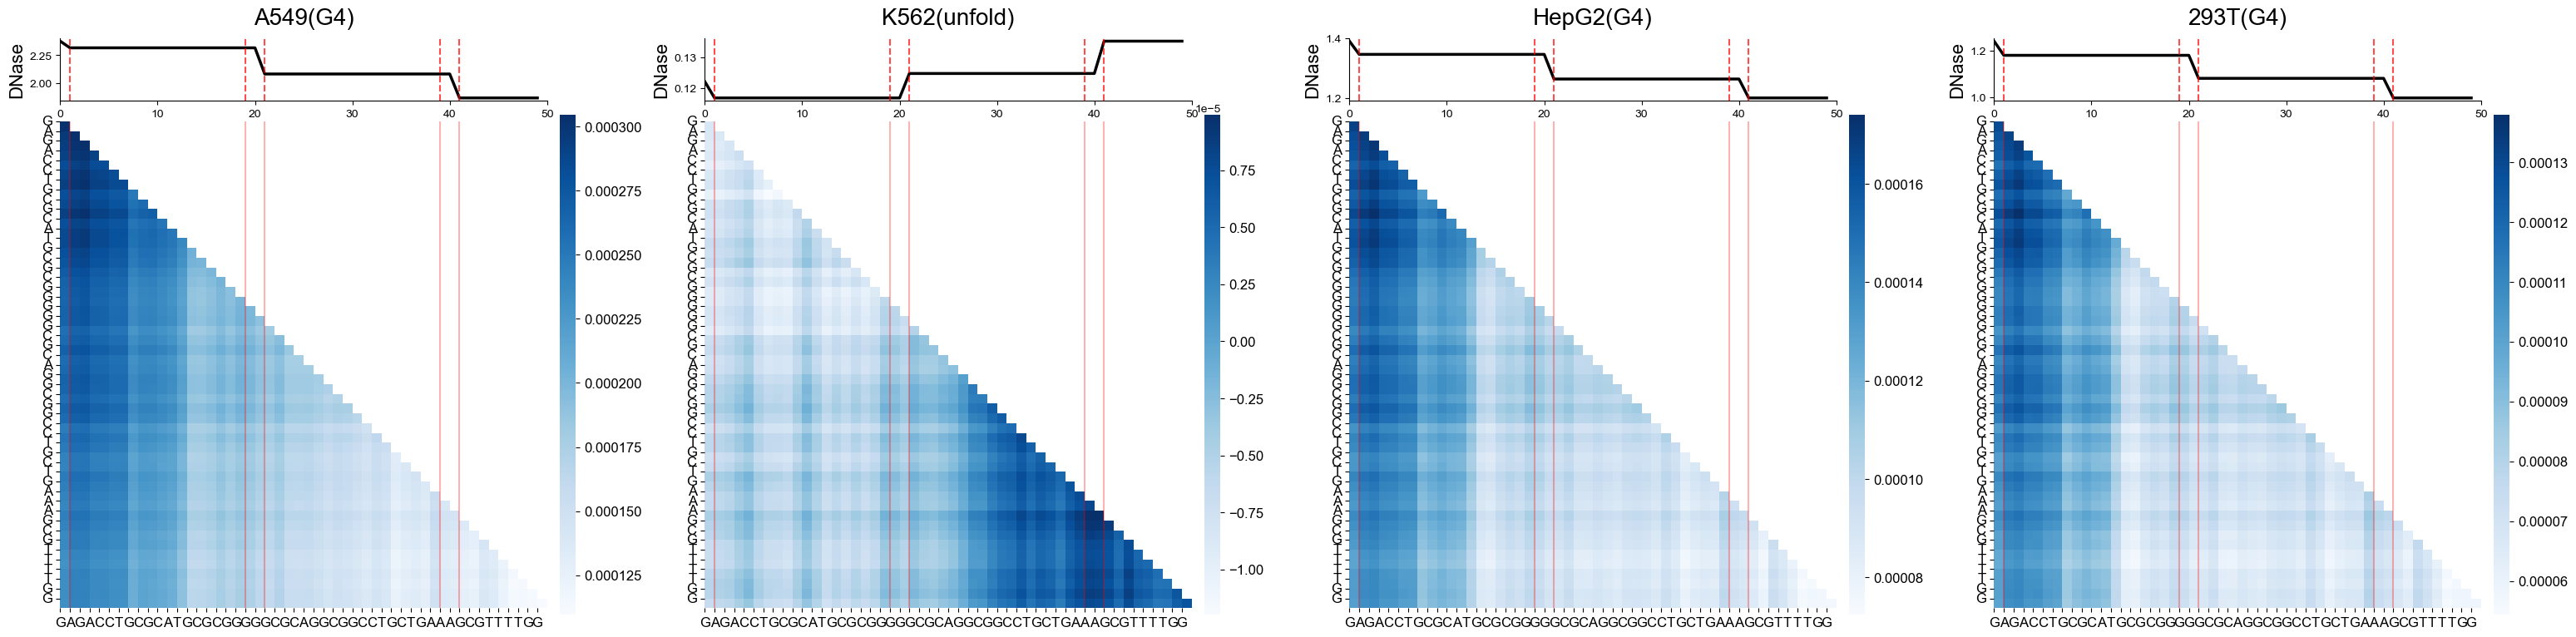

141
tensor([[ 2.2690, -0.1497]], device='cuda:2')
tensor([[0.5843, 0.6467]], device='cuda:2')


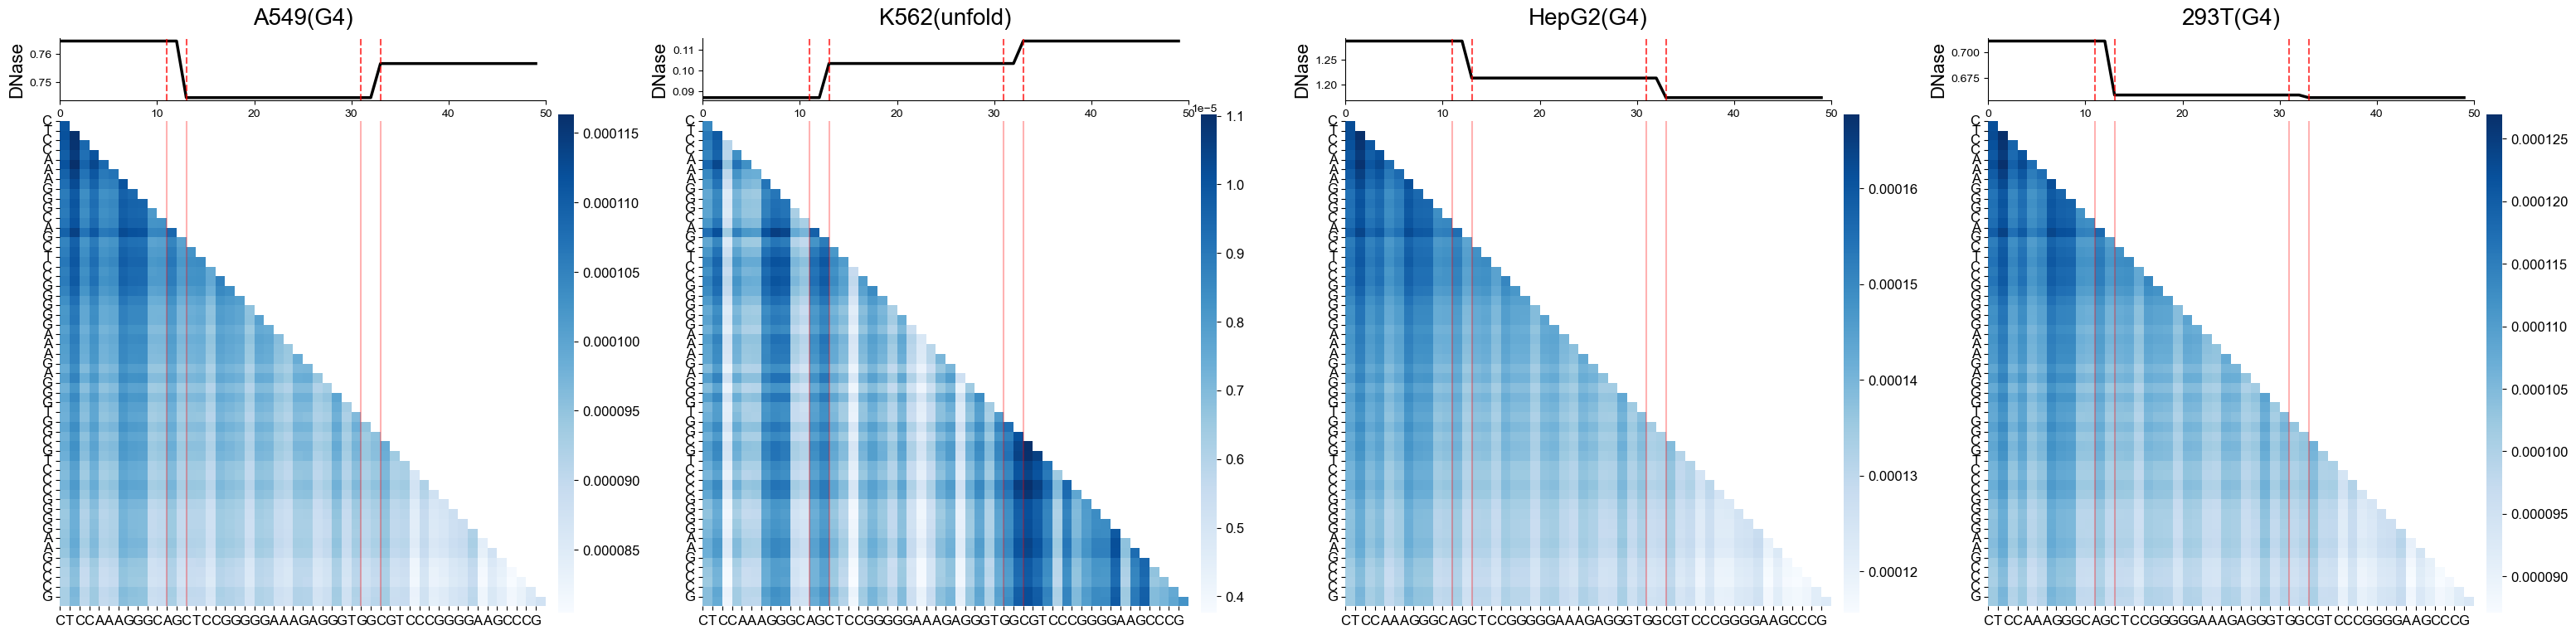

421
tensor([[ 2.1397, -0.3005]], device='cuda:2')
tensor([[ 2.1354, -0.3026]], device='cuda:2')


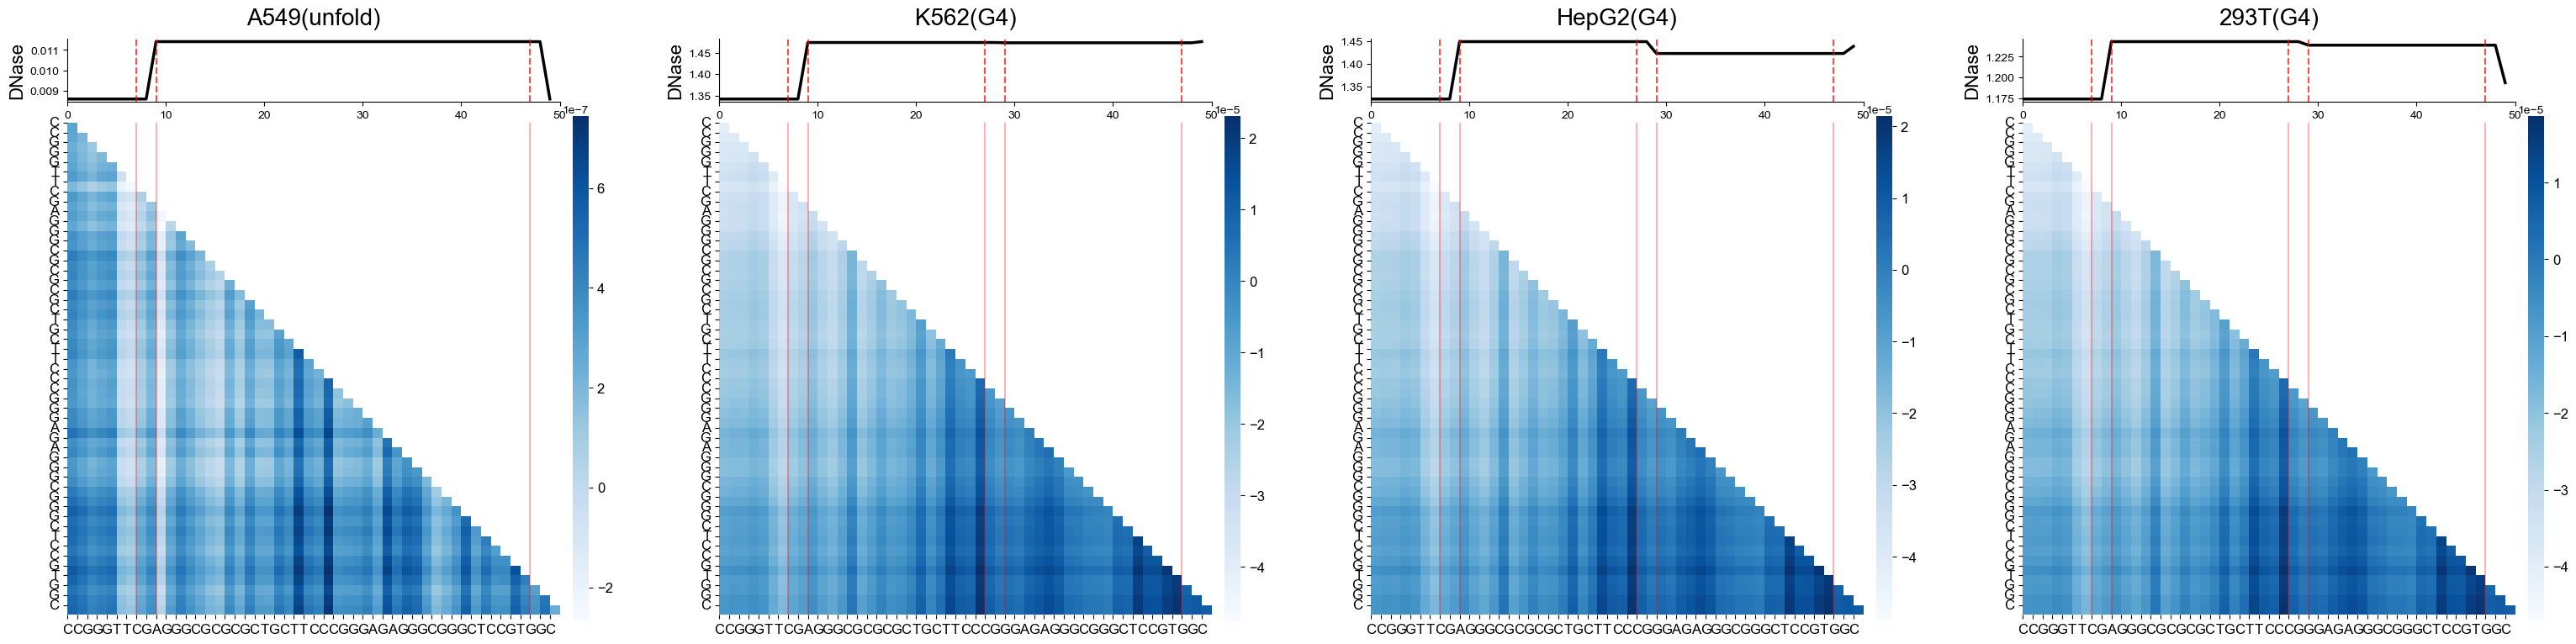

787


In [ ]:

device_ids = [ 2 ] 
criterion = nn.CrossEntropyLoss(  )
device = f"cuda:{device_ids[0]}"

best_model_wts = f'save_L1k_-11-58_epoch_1_64_{lr}_HepG2.pth'
if True:
    state_dict = torch.load(best_model_wts, map_location=device)            
    new_state_dict = {}
    for key, value in state_dict.items():
        # 移除开头的"module."
        new_key = key[7:] if key.startswith('module.') else key
        new_state_dict[new_key] = value

class G4former(nn.Module):
    def __init__(self):
        super(G4former, self).__init__()     

        self.adaptive_norm = AdaptiveLayerNorm(
            num_features=768, 
            conditions_dims=[ 1024 ]  # w 的条件维度，例如2或更多
        )
        self.fc2 = nn.Linear(1, 768)  # Second fully connected layer (optional)
        self.hidden_dim = 768

        self.classifier = nn.Linear(self.hidden_dim, 2)  # Binary classification
        self.activation = nn.GELU()  # Activation function

        self.pytorch_model = AutoModel.from_pretrained(
                "/home/hjzhang/ntv3G4/nucleotide_transformer_v3/NTv3_100m_post",
                    trust_remote_code=True
                )

        self.center_len = 50
        self.Block = Block(self.hidden_dim)


    def plot_attention(self, attn1, attn2, attn3, attn4,
                    w1, w2, w3, w4, ylist,
                    input_ids=None,
                    save_path="attention_map.png"):

        import numpy as np
        import matplotlib.pyplot as plt
        import matplotlib.gridspec as gridspec
        import seaborn as sns
        import matplotlib as mpl
        from matplotlib import font_manager

        # ===== Arial =====
        font_paths = [
            "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf",
        ]
        for fp in font_paths:
            font_manager.fontManager.addfont(fp)

        mpl.rcParams["font.family"] = "Arial"

        token_dict = {
            0:"<unk>",1:"<pad>",2:"<mask>",3:"<cls>",4:"<eos>",
            5:"<bos>",6:"A",7:"T",8:"C",9:"G",10:"N"
        }

        processed_attn = [
            attn1.detach().cpu().numpy(),
            attn2.detach().cpu().numpy(),
            attn3.detach().cpu().numpy(),
            attn4.detach().cpu().numpy()
        ]
        ws = [w1, w2, w3, w4]

        # ===== sequence label =====
        seq_labels = None
        if input_ids is not None:
            start_index = (input_ids.shape[1] - 50) // 2
            end_index = start_index + 50
            seq_tokens = input_ids[0, start_index:end_index].detach().cpu().numpy()
            seq_labels = [token_dict.get(int(i),"N") for i in seq_tokens]

        # ===== figure =====
        fig = plt.figure(figsize=(38,10))
        outer = gridspec.GridSpec(1,4, wspace=0.25)

        for i in range(4):

            inner = gridspec.GridSpecFromSubplotSpec(
                2,2,
                subplot_spec=outer[i],
                height_ratios=[1,8],
                width_ratios=[6,0.2],
                hspace=0.05,
                wspace=0.05
            )

            ax_top = plt.Subplot(fig, inner[0,0])
            ax_heat = plt.Subplot(fig, inner[1,0])
            ax_cbar = plt.Subplot(fig, inner[1,1])

            fig.add_subplot(ax_top)
            fig.add_subplot(ax_heat)
            fig.add_subplot(ax_cbar)

            att = processed_attn[i][0].mean(0)

            # mask upper triangle
            mask = np.triu(np.ones_like(att, dtype=bool), k=1)

            # ===== heatmap =====
            sns.heatmap(
                att,
                mask=mask,
                cmap="Blues",
                cbar=True,
                cbar_ax=ax_cbar,
                ax=ax_heat,
                square=True
            )

            # colorbar 字体
            cbar = ax_heat.collections[0].colorbar
            cbar.ax.tick_params(labelsize=12)

            # ===== ⭐ 标题移到最顶部（关键修改）=====
            if ylist[i] == 1:
                title_text = name_list[i] + "(G4)"
            else:
                title_text = name_list[i] + "(unfold)"

            ax_top.set_title(
                title_text,
                fontsize=20,        # 放大
                fontweight="bold",  # 加粗
                pad=12              # 和图的距离
            )

            # ===== sequence label =====
            if seq_labels is not None:
                L = min(len(seq_labels), att.shape[0])

                ax_heat.set_xticks(range(L))
                ax_heat.set_yticks(range(L))

                ax_heat.set_xticklabels(seq_labels[:L], rotation=0, fontsize=12)
                ax_heat.set_yticklabels(seq_labels[:L], rotation=0, fontsize=12)

            ax_heat.set_xlabel("")
            ax_heat.set_ylabel("")

            # ===== DNase =====
            dnase = ws[i][..., 0][start_index:end_index].detach().cpu().numpy()
            ax_top.plot(dnase, color="black", linewidth=2.5)

            grad = np.gradient(dnase)
            turning_points = np.where(np.diff(np.sign(grad)) != 0)[0]

            for idx in turning_points:
                ax_top.axvline(idx, color='red', linestyle='--', alpha=0.7)
                ax_heat.axvline(idx, color='red', alpha=0.3)

            ax_top.set_xlim(0, len(dnase))
            ax_top.set_ylabel("DNase", fontsize=16, fontweight="bold")

            # ⭐ 去掉多余边框（更干净）
            ax_top.spines['top'].set_visible(False)
            ax_top.spines['right'].set_visible(False)

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    def forward(self,input_ids,species_ids, w ):
        # input_ids = input_ids.float).long()
        outs = self.pytorch_model(input_ids, species_ids=species_ids )
        x  = outs.embedding # torch.Size([2, 288, 7362]) torch.Size([64, 256, 768]) 11 + 2

        cond = w # shape [B, L, 2]

        res = self.activation( self.fc2(cond[..., 1].unsqueeze(-1))) * cond[..., 1].unsqueeze(-1)
        # 通过 fc2 把 w 映射到同维度
        x = x + res 


        conditions = [ cond[..., 0]]
        # 用 AdaptiveLayerNorm 做条件调制
        x = self.adaptive_norm(x, conditions=conditions)
        outputs, attn = self.Block(x)
        if self.center_len:
            start_index = (outputs.shape[1] - self.center_len) // 2
            end_index = start_index + self.center_len
            x = outputs[:, start_index: end_index, :]
            start_index3 = (outputs.shape[1] - 50) // 2
            end_index3 = start_index3 + 50

        attn = attn[:, :, start_index3: end_index3,start_index3: end_index3]
        
        logits = self.classifier(x.mean(1))
        return logits, attn
    
    def reset_parameters(self):
        def init_layer(m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                nn.init.kaiming_uniform_(m.weight, a=math.sqrt(5))
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0, std=m.embedding_dim ** -0.5)
                # nn.init.uniform_(m.weight, -0.1, 0.1)            
            elif isinstance(m, (nn.LayerNorm, nn.BatchNorm1d)):
                if m.weight is not None:
                    nn.init.ones_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        # 递归应用到所有子模块
        self.fc2.apply(init_layer)
        self.classifier.apply(init_layer)
        
if True:
    if True:
        idx_save_path = f'L1k_1_k_{name}_test_idx_label_diff.pt'
        if os.path.exists(idx_save_path):
            print(f"Loading existing split indices from {idx_save_path}")
            test_idx = torch.load(idx_save_path)
            # test_idx = split_indices[name]

        idx_save_path = f'L1k_1_k_{name2}_test_idx_label_diff.pt'
        if os.path.exists(idx_save_path):
            print(f"Loading existing split indices from {idx_save_path}")
            test_idx2 = torch.load(idx_save_path)


        idx_save_path = f'L1k_1_k_{name3}_test_idx_label_diff.pt'
        if os.path.exists(idx_save_path):
            print(f"Loading existing split indices from {idx_save_path}")
            test_idx3 = torch.load(idx_save_path)


        idx_save_path = f'L1k_1_k_{name4}_test_idx_label_diff.pt'
        if os.path.exists(idx_save_path):
            print(f"Loading existing split indices from {idx_save_path}")
            test_idx4 = torch.load(idx_save_path)


        common_mask = torch.load("common_correct_test_idx.pt")

        common_test_idx = [
            test_idx[i]
            for i in range(len(test_idx))
            if common_mask[i]
        ]
        print( len(common_test_idx) )

        test_subset = torch.utils.data.Subset(dataset, common_test_idx)


        common_test_idx2 = [
            test_idx2[i]
            for i in range(len(test_idx2))
            if common_mask[i]
        ]
        test_subset2 = torch.utils.data.Subset(dataset2, common_test_idx2)

        common_test_idx3 = [
            test_idx3[i]
            for i in range(len(test_idx3))
            if common_mask[i]
        ]
        test_subset3 = torch.utils.data.Subset(dataset3, common_test_idx3)

        common_test_idx4 = [
            test_idx4[i]
            for i in range(len(test_idx4))
            if common_mask[i]
        ]
        test_subset4 = torch.utils.data.Subset(dataset4, common_test_idx4)

        model = G4former().to(device)
        model.load_state_dict(new_state_dict)
        model.eval()

        species_token = 27
        
        val_accs, val_losses = [] ,[]
        # ---------------------- 验证集：同步收集embedding和标签y ----------------------
        if True:
            val_loss, val_correct, val_total = 0, 0, 0
            val_preds, val_targets, val_probs = [], [], []
            with torch.no_grad():
                print(len(common_mask))
                for n in [13,141, 421, 787]:

                    input_ids, w, y,idx = test_subset[n]

                    input_ids, w1, y0 = input_ids.unsqueeze(0).to(device),  w.unsqueeze(0).to(device), y.to(device)

                    species_ids = torch.full((1,), species_token, dtype=torch.long).to(device)

                    w1_dnase0 = w1.clone()
                    w1_dnase0[..., 0] = 0
                    out, attn1_raw = model(input_ids, species_ids, w1_dnase0)
                    print(out)

                    out, attn1 = model(input_ids, species_ids, w1)
                    print(out)

                    input_ids2, w, y,idx2 = test_subset2[n]
                    input_ids2, w2, y2 = input_ids2.unsqueeze(0).to(device),  w.unsqueeze(0).to(device), y.to(device)
                    
                    if torch.equal(input_ids2, input_ids):
                        out2, attn2 = model(input_ids2, species_ids, w2)
                        w2_dnase0 = w2.clone()
                        w2_dnase0[...,0] = 0
                        out2, attn2_raw = model(input_ids2, species_ids, w2_dnase0)

                    else:
                        print("error")
                    input_ids3, w, y,idx3 = test_subset3[n]
                    input_ids3, w3, y3 = input_ids3.unsqueeze(0).to(device),  w.unsqueeze(0).to(device), y.to(device)
                    if torch.equal(input_ids3, input_ids):
                        out2, attn3 = model(input_ids3, species_ids, w3)
                        w3_dnase0 = w3.clone()
                        w3_dnase0[..., 0] = 0
                        out2, attn3_raw = model(input_ids3, species_ids, w3_dnase0)

                    else:
                        print("error")
                    input_ids4, w, y,idx4 = test_subset4[n]
                    input_ids4, w4, y4 = input_ids4.unsqueeze(0).to(device),  w.unsqueeze(0).to(device), y.to(device)
                    if torch.equal(input_ids4, input_ids):
                        out2, attn4 = model(input_ids4, species_ids, w4)
                        w4_dnase0 = w4.clone()
                        w4_dnase0[..., 0] = 0
                        out2, attn4_raw = model(input_ids4, species_ids, w4_dnase0)

                    else:
                        print("error")
                    ylist = [y0,y2,y3,y4]
                    model.plot_attention(attn1 - attn1_raw,attn2 - attn2_raw ,attn3- attn3_raw ,attn4- attn4_raw ,w1[0],w2[0],w3[0],w4[0], ylist,input_ids, f"/home/hjzhang/ntv3G4/home/Attention102/{n}.{y0}_.{y2}.{y3}.{y4}.pdf")
                    # model.plot_attention(attn2, input_ids, f"/home/hjzhang/ntv3G4/home/Attention/{name2}attention_{n}.{y2}.pdf")
                    # model.plot_attention(attn3, input_ids, f"/home/hjzhang/ntv3G4/home/Attention/{name3}attention_{n}.{y3}.pdf")

                    # model.plot_attention(attn4, input_ids, f"/home/hjzhang/ntv3G4/home/Attention/{name4}attention_{n}.{y4}.pdf")

                    # all_attn[locus_id] = {
                    #     name: attn1.cpu(),
                    #     name2: attn2.cpu(),
                    #     name3: attn3.cpu(),
                    #     name4: attn4.cpu()
                    # }

                    print( n )

Loading existing split indices from L1k_1_k_A549_test_idx_label_diff.pt
Loading existing split indices from L1k_1_k_K562_test_idx_label_diff.pt
Loading existing split indices from L1k_1_k_HepG2_test_idx_label_diff.pt
Loading existing split indices from L1k_1_k_293T_test_idx_label_diff.pt
1008


Some weights of the model checkpoint at /home/hjzhang/ntv3G4/nucleotide_transformer_v3/NTv3_100m_post were not used when initializing NTv3PostTrained: ['core.bed_head.head.bias', 'core.bed_head.head.weight', 'core.bed_head.layer_norm.bias', 'core.bed_head.layer_norm.weight', 'core.bigwig_head.species_heads.13.head.bias', 'core.bigwig_head.species_heads.13.head.weight', 'core.bigwig_head.species_heads.13.layer_norm.bias', 'core.bigwig_head.species_heads.13.layer_norm.weight', 'core.bigwig_head.species_heads.16.head.bias', 'core.bigwig_head.species_heads.16.head.weight', 'core.bigwig_head.species_heads.16.layer_norm.bias', 'core.bigwig_head.species_heads.16.layer_norm.weight', 'core.bigwig_head.species_heads.18.head.bias', 'core.bigwig_head.species_heads.18.head.weight', 'core.bigwig_head.species_heads.18.layer_norm.bias', 'core.bigwig_head.species_heads.18.layer_norm.weight', 'core.bigwig_head.species_heads.21.head.bias', 'core.bigwig_head.species_heads.21.head.weight', 'core.bigwig_hea

18818
tensor([[ 1.6397, -0.4914]], device='cuda:2')
tensor([[ 1.6363, -0.4915]], device='cuda:2')


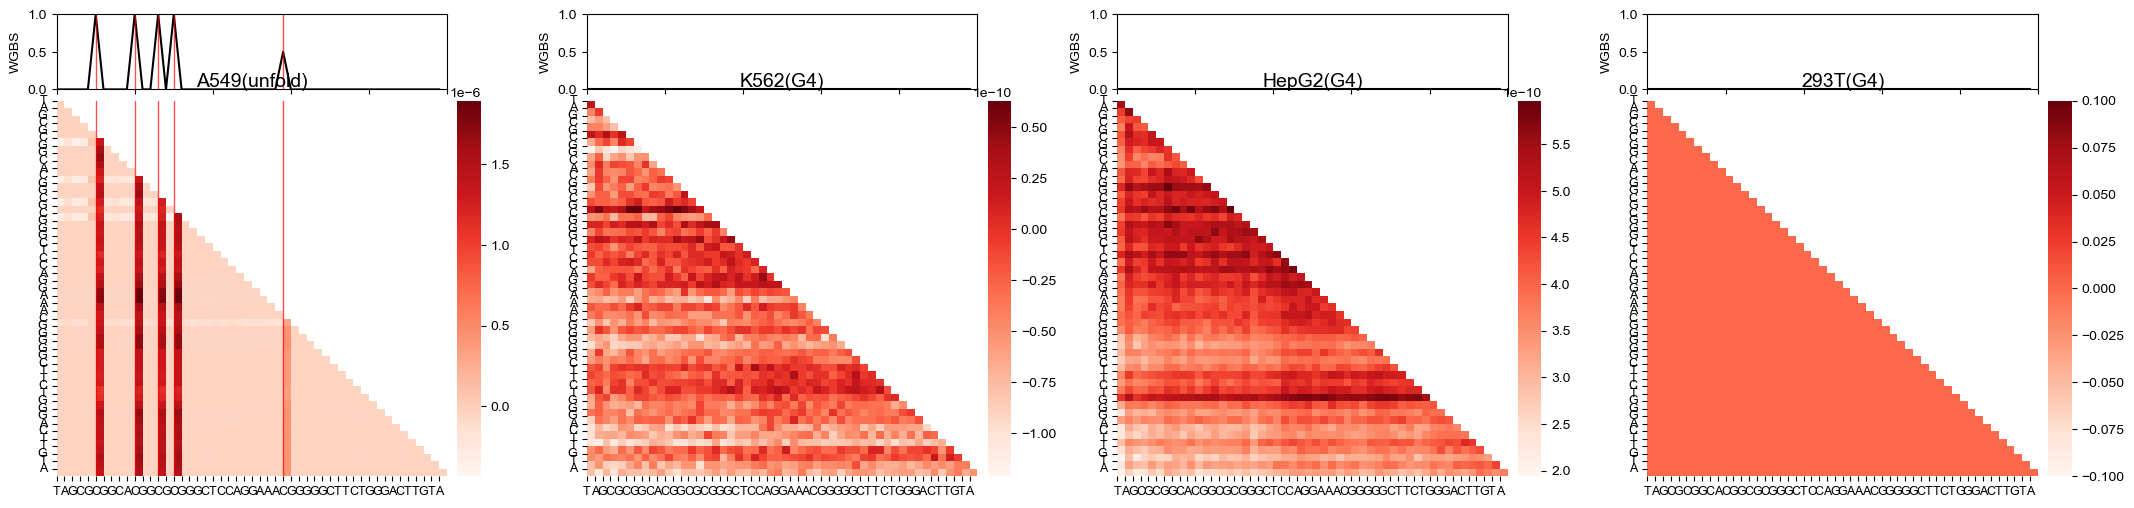

13
tensor([[-3.6836,  3.4432]], device='cuda:2')
tensor([[-3.6835,  3.4432]], device='cuda:2')


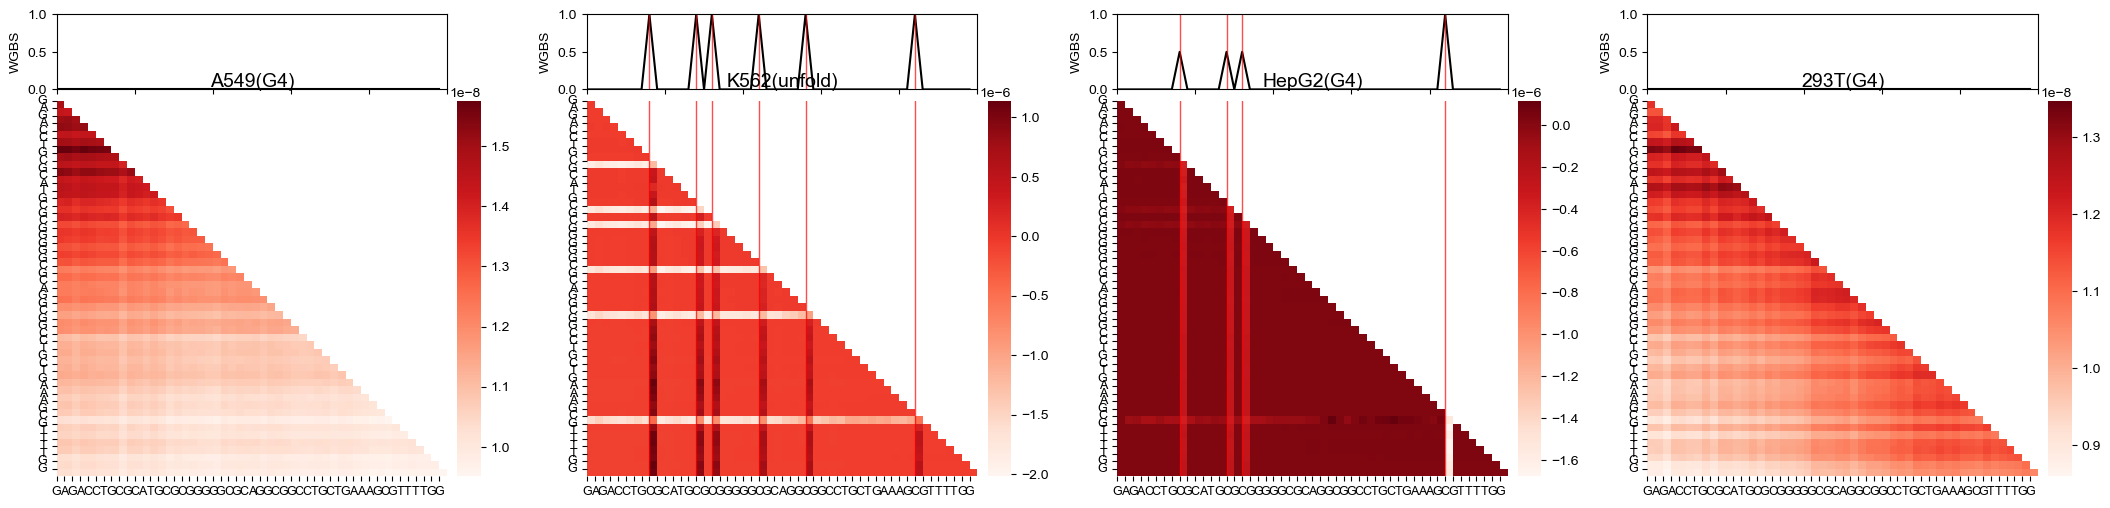

141
tensor([[0.5843, 0.6467]], device='cuda:2')
tensor([[0.5843, 0.6467]], device='cuda:2')


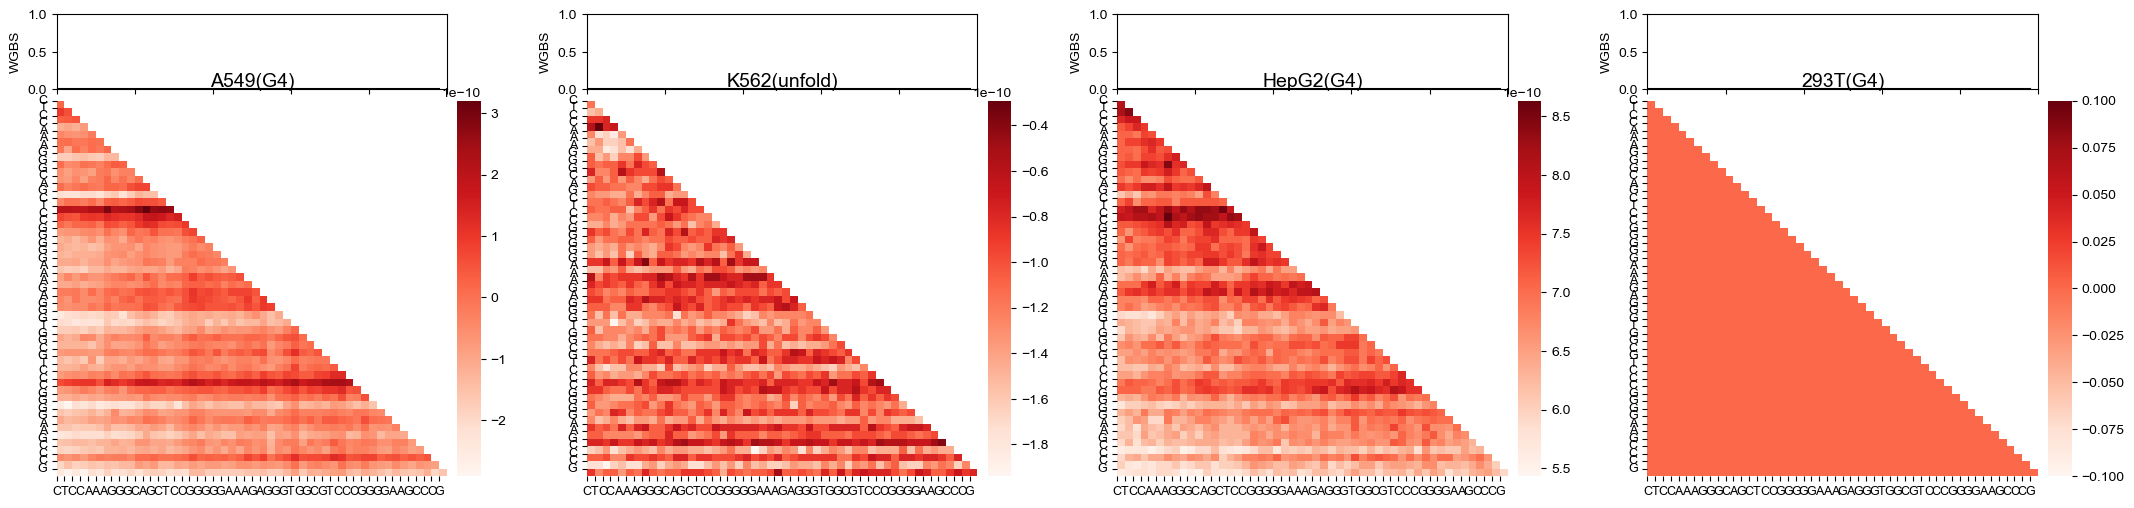

421
tensor([[ 2.1384, -0.3022]], device='cuda:2')
tensor([[ 2.1354, -0.3026]], device='cuda:2')


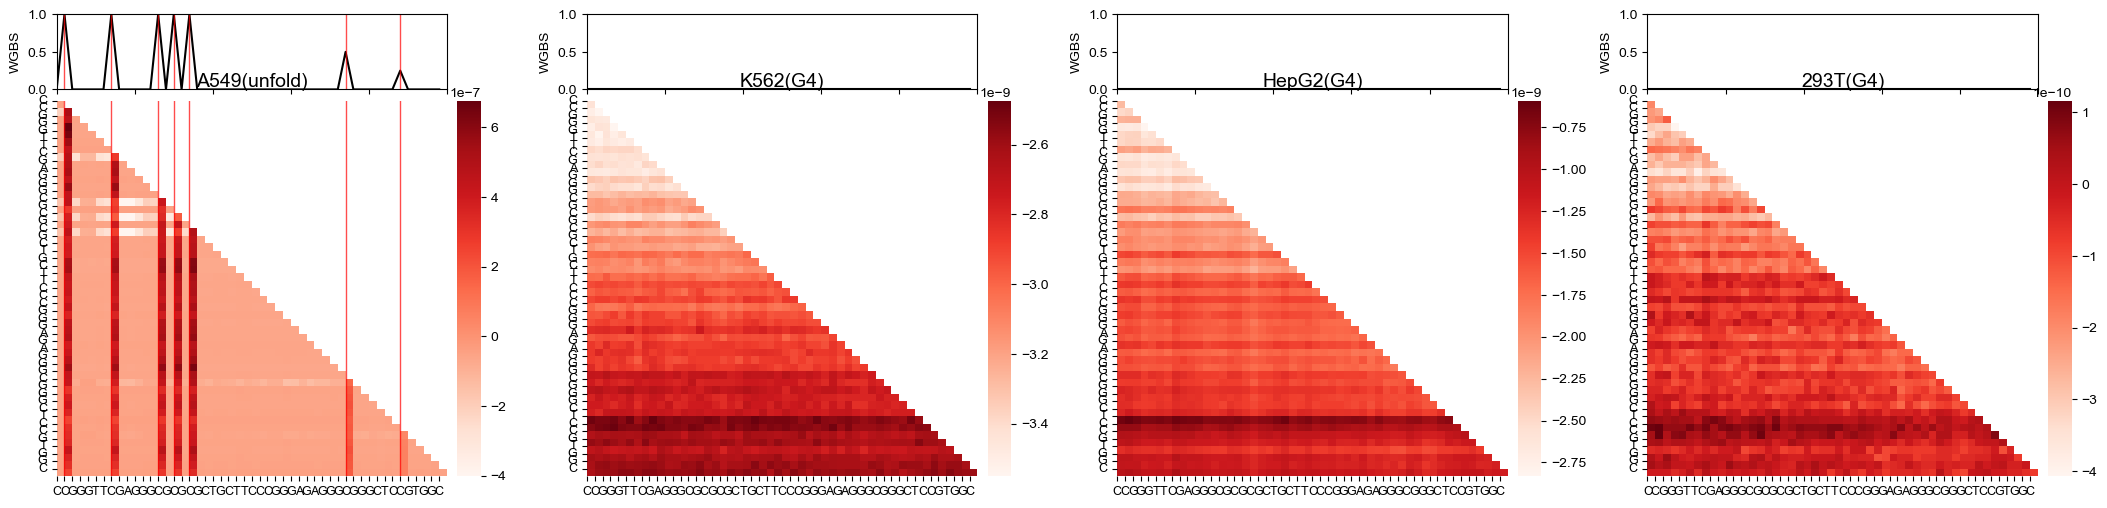

787


In [ ]:
class G4former(nn.Module):
    def __init__(self):
        super(G4former, self).__init__()     

        self.adaptive_norm = AdaptiveLayerNorm(
            num_features=768, 
            conditions_dims=[ 1024 ]  # w 的条件维度，例如2或更多
        )
        self.fc2 = nn.Linear(1, 768)  # Second fully connected layer (optional)
        self.hidden_dim = 768

        self.classifier = nn.Linear(self.hidden_dim, 2)  # Binary classification
        self.activation = nn.GELU()  # Activation function

        self.pytorch_model = AutoModel.from_pretrained(
                "/home/hjzhang/ntv3G4/nucleotide_transformer_v3/NTv3_100m_post",
                    trust_remote_code=True
                )

        self.center_len = 50
        self.Block = Block(self.hidden_dim)

    def plot_attention(self, attn1, attn2, attn3, attn4,
                    w1, w2, w3, w4, ylist,
                    input_ids=None,
                    save_path="attention_map.png"):

        import numpy as np
        import matplotlib.pyplot as plt
        import matplotlib.gridspec as gridspec
        import seaborn as sns
        import matplotlib as mpl
        from matplotlib import font_manager

        import matplotlib as mpl

        # ===== 手动注册 Arial（关键一步）=====

        font_paths = [

            "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf",

            "/usr/share/fonts/truetype/msttcorefonts/arialbd.ttf",

            "/usr/share/fonts/truetype/msttcorefonts/ariali.ttf",

            "/usr/share/fonts/truetype/msttcorefonts/arialbi.ttf",

        ]

        for fp in font_paths:

            font_manager.fontManager.addfont(fp)

        # ===== 强制使用 Arial =====

        mpl.rcParams["font.family"] = "Arial"
        token_dict = {
            0:"<unk>",1:"<pad>",2:"<mask>",3:"<cls>",4:"<eos>",
            5:"<bos>",6:"A",7:"T",8:"C",9:"G",10:"N"
        }

        processed_attn = [attn1.detach().cpu().numpy(), attn2.detach().cpu().numpy()
        , attn3.detach().cpu().numpy(), attn4.detach().cpu().numpy()]
        ws = [w1, w2, w3, w4]

        # ===== sequence label =====
        seq_labels = None
        if input_ids is not None:
            start_index = (input_ids.shape[1] - 50) // 2
            end_index = start_index + 50
            seq_tokens = input_ids[0, start_index:end_index].detach().cpu().numpy()
            seq_labels = [token_dict.get(int(i),"N") for i in seq_tokens]

        # ===== figure =====
        fig = plt.figure(figsize=(26,6))

        outer = gridspec.GridSpec(1,4, wspace=0.25)

        for i in range(4):

            inner = gridspec.GridSpecFromSubplotSpec(
                2,2,
                subplot_spec=outer[i],
                height_ratios=[1,5],
                width_ratios=[5,0.3],  # 最后一列是colorbar
                hspace=0.05,
                wspace=0.05
            )

            ax_top = plt.Subplot(fig, inner[0,0])
            ax_heat = plt.Subplot(fig, inner[1,0])
            ax_cbar = plt.Subplot(fig, inner[1,1])

            fig.add_subplot(ax_top)
            fig.add_subplot(ax_heat)
            fig.add_subplot(ax_cbar)

            att = processed_attn[i][0].mean(0)

            # mask upper triangle
            mask = np.triu(np.ones_like(att, dtype=bool), k=1)

            hm = sns.heatmap(
                att,
                mask=mask,
                cmap="Reds",
                cbar=True,
                cbar_ax=ax_cbar,
                ax=ax_heat
            )
            if ylist[i]==1:
                ax_heat.set_title(name_list[i]+f"(G4)", fontsize=14, pad=10)
            else:
                ax_heat.set_title(name_list[i]+f"(unfold)", fontsize=14, pad=10)
            if seq_labels is not None:

                L = min(len(seq_labels), att.shape[0])

                ax_heat.set_xticks(range(L))
                ax_heat.set_yticks(range(L))

                ax_heat.set_xticklabels(seq_labels[:L], rotation=0, fontsize=9)
                ax_heat.set_yticklabels(seq_labels[:L], rotation=0, fontsize=9)

            ax_heat.set_xlabel("")
            ax_heat.set_ylabel("")

            # ===== DNase =====
            dnase = ws[i][..., 1][start_index:end_index].detach().cpu().numpy()
            ax_top.plot(dnase, color="black")
            # ===== 🔥 找拐点 =====
            for pos, val in enumerate(dnase):
                if val > 0:   # 非0即认为有甲基化
                    ax_heat.axvline(
                        x=pos,
                        color="red",
                        linewidth=1,
                        alpha=0.7
                    )
                    ax_top.axvline(
                        x=pos,
                        color="red",
                        linewidth=1,
                        alpha=0.7
                    )
            ax_top.set_ylim(0, 1)

            ax_top.set_xlim(0,len(dnase))
            ax_top.set_ylabel("WGBS")
            ax_top.tick_params(axis='x', labelbottom=False)
            

        plt.tight_layout()

        plt.savefig(save_path, dpi=300, bbox_inches="tight")

        plt.show()
        plt.close()

    def forward(self,input_ids,species_ids,  w ):
        # input_ids = input_ids.float).long()
        outs = self.pytorch_model(input_ids, species_ids=species_ids )
        x  = outs.embedding # torch.Size([2, 288, 7362]) torch.Size([64, 256, 768]) 11 + 2

        cond = w # shape [B, L, 2]

        res = self.activation( self.fc2(cond[..., 1].unsqueeze(-1))) * cond[..., 1].unsqueeze(-1)
        # 通过 fc2 把 w 映射到同维度
        x = x + res 


        conditions = [ cond[..., 0]]
        # 用 AdaptiveLayerNorm 做条件调制
        x = self.adaptive_norm(conditions=conditions)
        outputs, attn = self.Block(x)
        if self.center_len:
            start_index = (outputs.shape[1] - self.center_len) // 2
            end_index = start_index + self.center_len
            x = outputs[:, start_index: end_index:]
            start_index3 = (outputs.shape[1] - 50) // 2
            end_index3 = start_index3 + 50

        attn = attn[:, :, start_index3: end_index3,start_index3: end_index3]
        
        logits = self.classifier(x.mean(1))
        return logits, attn
    
    def reset_parameters(self):
        def init_layer(m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        # 递归应用到所有子模块
        self.fc2.apply(init_layer)
        self.classifier.apply(init_layer)
      
if True:
    if True:
        idx_save_path = f'L1k_1_k_{name}_test_idx_label_diff.pt'
        if os.path.exists(idx_save_path):
            print(f"Loading existing split indices from {idx_save_path}")
            test_idx = torch.load(idx_save_path)
            # test_idx = split_indices[name]

        idx_save_path = f'L1k_1_k_{name2}_test_idx_label_diff.pt'
        if os.path.exists(idx_save_path):
            print(f"Loading existing split indices from {idx_save_path}")
            test_idx2 = torch.load(idx_save_path)


        idx_save_path = f'L1k_1_k_{name3}_test_idx_label_diff.pt'
        if os.path.exists(idx_save_path):
            print(f"Loading existing split indices from {idx_save_path}")
            test_idx3 = torch.load(idx_save_path)


        idx_save_path = f'L1k_1_k_{name4}_test_idx_label_diff.pt'
        if os.path.exists(idx_save_path):
            print(f"Loading existing split indices from {idx_save_path}")
            test_idx4 = torch.load(idx_save_path)


        common_mask = torch.load("common_correct_test_idx.pt")

        common_test_idx = [
            test_idx[i]
            for i in range(len(test_idx))
            if common_mask[i]
        ]
        print( len(common_test_idx) )

        test_subset = torch.utils.data.Subset(dataset, common_test_idx)


        common_test_idx2 = [
            test_idx2[i]
            for i in range(len(test_idx2))
            if common_mask[i]
        ]
        test_subset2 = torch.utils.data.Subset(dataset2, common_test_idx2)

        common_test_idx3 = [
            test_idx3[i]
            for i in range(len(test_idx3))
            if common_mask[i]
        ]
        test_subset3 = torch.utils.data.Subset(dataset3, common_test_idx3)

        common_test_idx4 = [
            test_idx4[i]
            for i in range(len(test_idx4))
            if common_mask[i]
        ]
        test_subset4 = torch.utils.data.Subset(dataset4, common_test_idx4)

        model = G4former().to(device)
        model.load_state_dict(new_state_dict)
        model.eval()

        species_token = 27
        
        val_accs, val_losses = [] ,[]
        # ---------------------- 验证集：同步收集embedding和标签y ----------------------
        if True:
            val_loss, val_correct, val_total = 0, 0, 0
            val_preds, val_targets, val_probs = [], [], []
            with torch.no_grad():
                print(len(common_mask))
                for n in [13,141, 421, 787]:

                    input_ids, w, y,idx = test_subset[n]

                    input_ids, w1, y0 = input_ids.unsqueeze(0).to(device),  w.unsqueeze(0).to(device), y.to(device)

                    species_ids = torch.full((1,), species_token, dtype=torch.long).to(device)

                    w1_dnase0 = w1.clone()
                    w1_dnase0[..., 1] = 0
                    out, attn1_raw = model(input_ids, species_ids, w1_dnase0)
                    print(out)


                    out, attn1 = model(input_ids, species_ids, w1)
                    print(out)

                    input_ids2, w, y,idx2 = test_subset2[n]
                    input_ids2, w2, y2 = input_ids2.unsqueeze(0).to(device),  w.unsqueeze(0).to(device), y.to(device)
                    
                    if torch.equal(input_ids2, input_ids):
                        out2, attn2 = model(input_ids2, species_ids, w2)
                        w2_dnase0 = w2.clone()
                        w2_dnase0[..., 1] = 0
                        out2, attn2_raw = model(input_ids2, species_ids, w2_dnase0)

                    else:
                        print("error")
                    input_ids3, w, y,idx3 = test_subset3[n]
                    input_ids3, w3, y3 = input_ids3.unsqueeze(0).to(device),  w.unsqueeze(0).to(device), y.to(device)
                    if torch.equal(input_ids3, input_ids):
                        out2, attn3 = model(input_ids3, species_ids, w3)
                        w3_dnase0 = w3.clone()
                        w3_dnase0[..., 1] = 0
                        out2, attn3_raw = model(input_ids3, species_ids, w3_dnase0)

                    else:
                        print("error")
                    input_ids4, w, y,idx4 = test_subset4[n]
                    input_ids4, w4, y4 = input_ids4.unsqueeze(0).to(device),  w.unsqueeze(0).to(device), y.to(device)
                    if torch.equal(input_ids4, input_ids):
                        out2, attn4 = model(input_ids4, species_ids, w4)
                        w4_dnase0 = w4.clone()
                        w4_dnase0[..., 1] = 0
                        out2, attn4_raw = model(input_ids4, species_ids, w4_dnase0)

                    else:
                        print("error")
                    ylist = [y0, y2, y3, y4]
                    model.plot_attention(attn1 - attn1_raw, attn2 - attn2_raw, attn3- attn3_raw, attn4- attn4_raw ,w1[0], w2[0], w3[0], w4[0], ylist,input_ids, f"/home/hjzhang/ntv3G4/home/Attention103/{n}.{y0}_.{y2}.{y3}.{y4}.pdf")

                    print( n )